# 18_归一化方法-最小-最大缩放

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


我们今天来聊聊，归一化方法：最小-最大缩放\~

这个方法在日常的实验中用的非常多，我们先来简单解释一下：

想象有一堆不同单位、范围差异很大的数据，比如：

- 一列是身高（单位：cm），范围是 150 到 190。
- 一列是收入（单位：万元），范围是 1 到 100。

如果我们把这些数据直接喂给机器学习算法，它会「误以为」收入比身高更重要（因为数字大），虽然这可能不是我们想要的。

### 所以怎么办呢？

我们想让**所有的特征值都变到一个统一的范围**，比如 [0, 1] 之间。

这时候，「最小-最大缩放」就登场了！

这个方法就是：

> 把一个数减去最小值，再除以最大值和最小值的差。

这样处理完之后：

- 最小的那个数就会变成 0；
- 最大的那个数就会变成 1；
- 其他数都会被线性拉伸到 0 到 1 之间。

---

### 举个例子

假设有三个学生的成绩：

| 姓名 | 成绩（原始分数） |
|-|-|
| 小明 | 70 |
| 小红 | 80 |
| 小刚 | 100 |

我们希望把成绩归一化到 [0, 1] 范围内。

#### 第一步：找最小值和最大值

- 最小值 = 70
- 最大值 = 100

#### 第二步：应用公式

公式如下：


$$
x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$$


- 小明的新分数：


$$
\frac{70 - 70}{100 - 70} = \frac{0}{30} = 0
$$


- 小红的新分数：


$$
\frac{80 - 70}{100 - 70} = \frac{10}{30} ≈ 0.333
$$


- 小刚的新分数：


$$
\frac{100 - 70}{100 - 70} = \frac{30}{30} = 1
$$


最终结果如下：

| 姓名 | 原始分数 | 归一化后 |
|-|-|-|
| 小明 | 70 | 0 |
| 小红 | 80 | 0.333 |
| 小刚 | 100 | 1 |

## 核心原理

### 原始设定

设某个特征的原始数据是 $x$，在该列中：

- 最小值是 $x_{\min}$
- 最大值是 $x_{\max}$

我们希望将数据线性映射到一个新范围 $[a, b]$，最常见的是 $[0, 1]$。

### 推导步骤

#### Step 1: 平移数据（把最小值移到0）

首先，把所有数据都减去最小值 $x_{\min}$，也就是：


$$
x - x_{\min}
$$


此时最小值就变成 0，最大值变成 $x_{\max} - x_{\min}$。

#### Step 2: 缩放数据（让最大值变成1）

接下来，除以最大-最小的差：


$$
\frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$


这样，最大值就被拉伸到 1。

#### Step 3（可选）：映射到任意区间 [a, b]

如果你不想把数据缩放到 [0, 1]，而是 [a, b]，只需多乘以 $b - a$ 然后加上 $a$：


$$
x' = a + \frac{(x - x_{\min}) \cdot (b - a)}{x_{\max} - x_{\min}}
$$


## 算法流程

适用于每一列（每个特征）：

#### 输入：原始数据集中的某一列（一个特征）$x_1, x_2, ..., x_n$

#### 目标：得到归一化后的新数据 $x_1', x_2', ..., x_n'$

#### 步骤：

1. **找出最小值和最大值**


$$
x_{\min} = \min(x_1, ..., x_n) \\x_{\max} = \max(x_1, ..., x_n)
$$


1. **对每个值应用归一化公式**


$$
x_i' = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}, \quad \text{对所有 } i = 1, 2, ..., n
$$


1. **输出归一化后的新数据**

注意点：

如果 $x_{\min} = x_{\max}$，说明这一列数据都一样，不能做缩放，会导致除以 0。一般要额外处理，比如全部归为 0 或 1。

最小-最大缩放**对异常值很敏感**，如果有极大或极小的异常值，会拉伸整个范围。

总的来说，最小-最大缩放就是：把一个数按它在原始数据中的位置，线性地映射到一个新范围（通常是 [0, 1]），让各个特征处在同一个尺度，便于比较和建模。

## 完整案例

这里咱们使用「最小-最大缩放」对真实模拟的健康数据进行处理与分析。

假设正在处理一份健康体检数据，包含以下三类连续变量：

- 血压（Blood Pressure）
- 血糖（Glucose）
- 胆固醇（Cholesterol）

数据中包含**离群值（异常值）**，为了构建一个更稳定、可比较的模型，需要进行归一化处理。

### 第一步：数据集

我们使用 NumPy 生成一个模拟数据集，包含离群点：

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# 生成一个复杂的数据集，包含多个数值特征和异常值
np.random.seed(42)

# 模拟体检数据（例如：血压、血糖、胆固醇等）
data = {
    "BloodPressure": np.random.normal(120, 15, 100).tolist() + [300],  # 异常高血压
    "Glucose": np.random.normal(100, 20, 100).tolist() + [10],         # 异常低血糖
    "Cholesterol": np.random.normal(200, 30, 100).tolist() + [500],    # 异常高胆固醇
}
df = pd.DataFrame(data)

正态分布生成大部分正常值，额外加入极端值以模拟真实场景中的数据异常。

---

### 第二步：进行最小-最大归一化

In [3]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

`MinMaxScaler()` 用于将所有特征映射到 [0, 1]，`.fit_transform()` 会计算每列的最小/最大值并进行转换；

转换后的数据保持列名一致，方便后续处理。

### 第三步：可视化对比前后分布

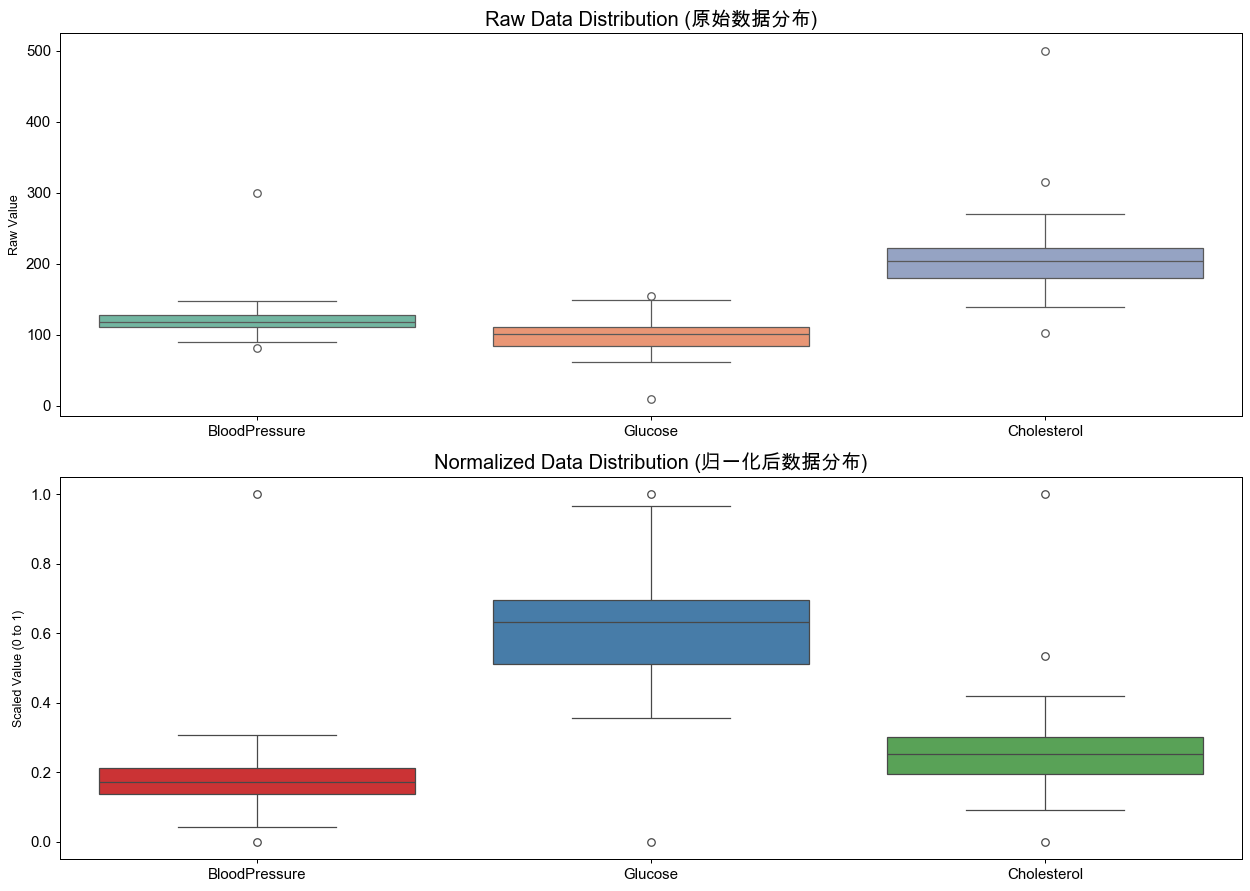

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10))

# 原始数据分布（含异常值）
sns.boxplot(data=df, ax=axs[0], palette='Set2')
axs[0].set_title("Raw Data Distribution (原始数据分布)", fontsize=16)
axs[0].set_ylabel("Raw Value")
axs[0].tick_params(labelsize=12)

# 归一化后的数据
sns.boxplot(data=df_scaled, ax=axs[1], palette='Set1')
axs[1].set_title("Normalized Data Distribution (归一化后数据分布)", fontsize=16)
axs[1].set_ylabel("Scaled Value (0 to 1)")
axs[1].tick_params(labelsize=12)

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_017.png)

- 第一张图展示了原始数据的分布，包括一些显著的异常点（例如血压达到300）；
- 第二张图展示归一化后的效果，所有特征都被压缩到 [0, 1]，但**异常值对整体分布影响依然存在**；
- 使用 Seaborn 配色 Set1 和 Set2 提高可读性。

整个流程，比较简单，大家在后面的实验中大概率会用到，我们再来总结梳理一下：

1. 使用 NumPy 构造了带异常值的现实数据；
2. 使用 MinMaxScaler 实现了「最小-最大缩放」；
3. 用 Boxplot 图形对比了归一化前后变化，让特征值处于统一尺度；
4. 归一化后数据更适合用于神经网络、KNN等依赖距离或梯度的算法。

## 模型分析

### 优缺点分析

**优点：**

1. **直观简单**：易于理解，公式易实现；
2. **保留原始数据的分布形状**：不会改变数据的相对关系；
3. **适合距离度量算法**：如KNN、KMeans、SVM、深度学习等非常依赖尺度统一；
4. **可映射到任意范围**：不仅限于 [0, 1]，也可以映射到 [-1, 1] 等范围。

**缺点：**

1. **对异常值敏感**：一两个极端值会“压缩”其他数据，降低区分度；
2. **仅对测试集有效**：必须用训练集的 min/max 来归一化测试集，避免数据泄漏；
3. **不适合有大量异常值的数据分布**：归一化后很多正常值可能集中在0附近。

### 与相似算法的对比

| 方法 | 原理公式 | 是否受异常值影响 | 范围 | 适合的算法/场景 |
|-|-|-|-|-|
| 最小-最大缩放 | $(x - min) / (max - min)$ | 非常敏感 | 自定义（如 [0,1]） | 距离算法（KNN、SVM、神经网络） |
| Z-score 标准化 | $(x - \mu)/\sigma$ | 较稳健 | 理论上无界 | 对异常值要求较高、分布较平稳的数据 |
| MaxAbs 缩放 | $x' = \frac{x}{\\|x\\|_{\max}} = \frac{x}{\max(\\|x_1\\|, \\|x_2\\|, \dots, \\|x_n\\|)}$ | 一般敏感 | [-1, 1] | 稀疏数据（如文本数据） |
| RobustScaler | 基于中位数和四分位数缩放 | 非常鲁棒 | 不一定固定 | 数据中存在多个离群值时 |
| Log 转换/Box-Cox | 使用函数变换如 $\log(x + 1)$ 或 Box-Cox | 取决于函数 | 不一定固定 | 数据呈长尾分布或偏态分布 |

### 什么时候该选最小-最大缩放？

**推荐使用的情况：**

- 特征数值单位不统一，例如：收入（万元）、身高（cm）、面积（㎡）；
- 数据分布大致均衡，没有太多极端值；
- 用于依赖距离度量或梯度方向的算法，例如：

  - KNN（近邻法）；
  - KMeans（聚类）；
  - 支持向量机（SVM）；
  - 神经网络（特别是带激活函数如sigmoid的模型）；

**不推荐使用的情况：**

- 数据中包含较多异常值；
- 特征本身已经标准化或是类别数据；
- 需要解释性强的模型（如线性回归、决策树）中，特征归一化可能不会有太大帮助。

### 总结

最小-最大缩放是最常用的归一化方法之一，操作简单且适配性强；

但它对异常值极其敏感，如果数据中有明显离群点，可以考虑使用 RobustScaler 或 Z-score；